<a href="https://colab.research.google.com/github/Markwema86/Google-Trends-Economic-Data-scraper/blob/main/Google_Trends_%2B_Economic_Data_scraper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install pytrends pandas matplotlib
import pytrends
print("Ready")

Ready


African Market Intelligence Pipeline

What am Building

     AFRICAN MARKET INTELLIGENCE PIPELINE       
                                               
    **PART 1 - Google Trends **                        
    Track consumer interest across 5 African markets as a leading economic indicator        
                                              
    **PART 2 - World Bank API**                        
    Pull official macro data - GDP, inflation, FX, debt levels per country                    
                                                 
    **PART 3 - Combine & Score **                      
    Merge both sources into a country attractiveness index for PE/DFI investors

**Part 1 - Google Trends: Consumer Pulse Across Africa**

**Step 1** - Understand what we are Measuring

Google Trends measures search interest - how often people in a country search for a term, normalised to 100. It's a real-time proxy for:

- **Consumer confidence** (people searching "buy car", "new phone")

- **Economic stress** (people searching "loan", "job vacancy")

- **Sector growth** (people searching "mobile banking", "solar panel")

PE firms and hedge funds pay millions for this kind of alternative data.

In [59]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import time

# Initialise connection to Google Trends
pytrends = TrendReq(hl='en-US', tz=360)

print("Google Trends connection established.")
print("We will track consumer and economic search trends")
print("across Kenya, Nigeria, Ghana, South Africa and Egypt.")

Google Trends connection established.
We will track consumer and economic search trends
across Kenya, Nigeria, Ghana, South Africa and Egypt.


**Step 2** - Track Mobile Banking Interest (Fintech Signal)

Mobile banking adoption is one of the strongest indicators of financial sector maturity in Africa - directly relevant to AfriPay-type investments.

In [60]:
# Define our 5 target markets
countries = {
    'Kenya':        'KE',
    'Nigeria':      'NG',
    'Ghana':        'GH',
    'South Africa': 'ZA',
    'Egypt':        'EG'
}

# Track mobile banking search interest per country
fintech_trends = {}

for country_name, country_code in countries.items():
    try:
        pytrends.build_payload(
            kw_list=['mobile banking'],
            cat=0,
            timeframe='today 5-y',
            geo=country_code
        )
        data = pytrends.interest_over_time()

        if not data.empty:
            fintech_trends[country_name] = data['mobile banking']
            print(f"✓ {country_name} — {len(data)} weeks of data pulled")

        time.sleep(2)  # Respectful delay — don't hammer Google's servers

    except Exception as e:
        print(f"✗ {country_name} — Error: {e}")

# Combine into one DataFrame
fintech_df = pd.DataFrame(fintech_trends)
print(f"\nData shape: {fintech_df.shape}")
print(fintech_df.tail(5))

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ Kenya — 261 weeks of data pulled


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ Nigeria — 261 weeks of data pulled


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ Ghana — 261 weeks of data pulled


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ South Africa — 261 weeks of data pulled


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ Egypt — 261 weeks of data pulled

Data shape: (261, 5)
            Kenya  Nigeria  Ghana  South Africa  Egypt
date                                                  
2026-04-26     49       24     60            44     46
2026-05-03     41       19     53            35     33
2026-05-10     30       18     66            29     59
2026-05-17     34       22     57            28     41
2026-05-24     40       21     66            30     40


**Step 3** - Track Multiple Economic Signals

In [61]:
# Keywords that signal different economic conditions
economic_signals = {
    'fintech_growth':    'mobile banking',
    'consumer_spend':    'online shopping',
    'economic_stress':   'personal loan',
    'job_market':        'job vacancy',
    'solar_adoption':    'solar panel'
}

# Pull all signals for Kenya as our primary market
kenya_signals = {}

for signal_name, keyword in economic_signals.items():
    try:
        pytrends.build_payload(
            kw_list=[keyword],
            cat=0,
            timeframe='today 5-y',
            geo='KE'
        )
        data = pytrends.interest_over_time()

        if not data.empty:
            kenya_signals[signal_name] = data[keyword]
            avg = data[keyword].mean()
            trend = "↑ Rising" if data[keyword].iloc[-12:].mean() > \
                                   data[keyword].iloc[-24:-12].mean() \
                    else "↓ Falling"
            print(f"✓ {signal_name:20} avg={avg:.1f}  {trend}")

        time.sleep(2)

    except Exception as e:
        print(f"✗ {signal_name} — {e}")

kenya_df = pd.DataFrame(kenya_signals)
print(f"\nKenyan economic signals shape: {kenya_df.shape}")

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ fintech_growth       avg=55.0  ↓ Falling


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ consumer_spend       avg=70.7  ↓ Falling


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ economic_stress      avg=46.1  ↑ Rising


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ job_market           avg=57.1  ↓ Falling


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✓ solar_adoption       avg=58.2  ↓ Falling

Kenyan economic signals shape: (261, 5)


**Step 4** - Visualise The Trends

/tmp/ipykernel_495/2974517200.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  smoothed = series.resample('M').mean()
/tmp/ipykernel_495/2974517200.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  smoothed = series.resample('M').mean()


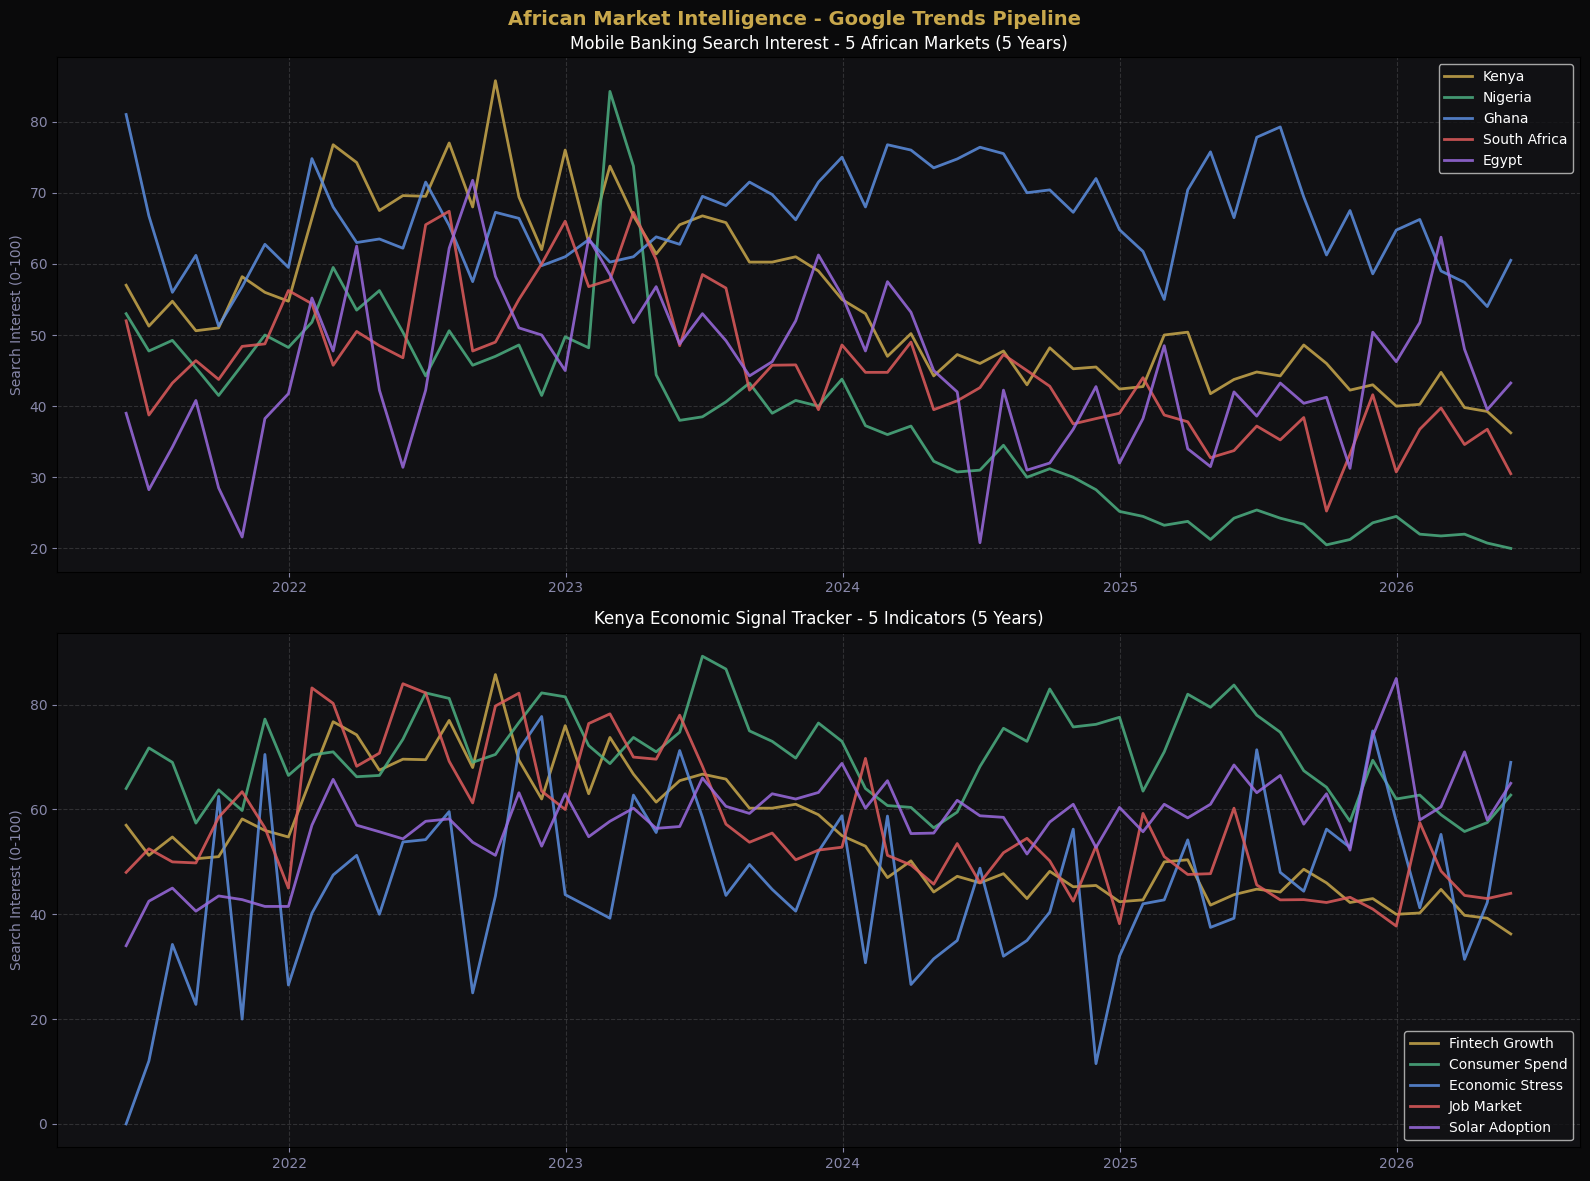

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.patch.set_facecolor('#0A0A0B')

#  TOP: Mobile banking across all 5 countries
ax1 = axes[0]
colors = ['#C9A84C', '#4CAF82', '#5C8EE0', '#E05C5C', '#9B6BE0']

for (country, series), color in zip(fintech_df.items(), colors):
    # Monthly smoothing for cleaner lines
    smoothed = series.resample('M').mean()
    ax1.plot(smoothed.index, smoothed.values,
             label=country, color=color,
             linewidth=2, alpha=0.85)

ax1.set_facecolor('#111114')
ax1.set_title('Mobile Banking Search Interest - 5 African Markets (5 Years)',
              color='white', fontsize=12)
ax1.set_ylabel('Search Interest (0-100)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.legend(facecolor='#111114', labelcolor='white')
ax1.grid(linestyle='--', alpha=0.2)

#  BOTTOM: Kenya economic signals
ax2 = axes[1]
signal_colors = ['#C9A84C', '#4CAF82', '#5C8EE0', '#E05C5C', '#9B6BE0']

for (signal, series), color in zip(kenya_df.items(), signal_colors):
    smoothed = series.resample('M').mean()
    ax2.plot(smoothed.index, smoothed.values,
             label=signal.replace('_', ' ').title(),
             color=color, linewidth=2, alpha=0.85)

ax2.set_facecolor('#111114')
ax2.set_title('Kenya Economic Signal Tracker - 5 Indicators (5 Years)',
              color='white', fontsize=12)
ax2.set_ylabel('Search Interest (0-100)', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white')
ax2.grid(linestyle='--', alpha=0.2)

plt.suptitle('African Market Intelligence - Google Trends Pipeline',
             color='#C9A84C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Step 5** - Score Each Country's Trend Momentum

In [63]:
# Calculate trend momentum score per country
# Comparing last 6 months vs prior 6 months

print("=== COUNTRY TREND MOMENTUM SCORES ===\n")

momentum_scores = {}

for country in fintech_df.columns:
    series = fintech_df[country].resample('M').mean()

    if len(series) >= 12:
        recent_6m   = series.iloc[-6:].mean()
        prior_6m    = series.iloc[-12:-6].mean()
        momentum    = ((recent_6m - prior_6m) / prior_6m * 100)
        current_lvl = series.iloc[-1]

        momentum_scores[country] = {
            'Current Interest':  round(current_lvl, 1),
            'Recent 6M Avg':     round(recent_6m, 1),
            'Prior 6M Avg':      round(prior_6m, 1),
            'Momentum %':        round(momentum, 1),
            'Signal':            '↑ GROWING' if momentum > 5
                                 else '↓ DECLINING' if momentum < -5
                                 else '→ STABLE'
        }

        print(f"{country:15} | Interest: {current_lvl:5.1f} | "
              f"Momentum: {momentum:+.1f}% | "
              f"{'↑ GROWING' if momentum > 5 else '↓ DECLINING' if momentum < -5 else '→ STABLE'}")

momentum_df = pd.DataFrame(momentum_scores).T

=== COUNTRY TREND MOMENTUM SCORES ===

Kenya           | Interest:  36.2 | Momentum: -10.6% | ↓ DECLINING
Nigeria         | Interest:  20.0 | Momentum: -5.3% | ↓ DECLINING
Ghana           | Interest:  60.5 | Momentum: -12.5% | ↓ DECLINING
South Africa    | Interest:  30.5 | Momentum: -0.9% | → STABLE
Egypt           | Interest:  43.2 | Momentum: +19.3% | ↑ GROWING


/tmp/ipykernel_495/1383795158.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = fintech_df[country].resample('M').mean()


**Part 2 - World Bank API: Official Macro Data**

Google Trends tells you what consumers are doing. World Bank tells you what the economy is doing. Together they're powerful.

In [64]:
!pip install world-bank-data

In [65]:
import world_bank_data as wb

# Define our indicator codes
# These are World Bank's official metric IDs
indicators = {
    'GDP_growth':        'NY.GDP.MKTP.KD.ZG',  # GDP growth rate %
    'Inflation':         'FP.CPI.TOTL.ZG',      # Consumer price inflation %
    'FDI_inflows':       'BX.KLT.DINV.WD.GD.ZS',# FDI as % of GDP
    'Unemployment':      'SL.UEM.TOTL.ZS',       # Unemployment rate %
    'Debt_to_GDP':       'GC.DOD.TOTL.GD.ZS',   # Government debt % of GDP
    'Mobile_penetration':'IT.CEL.SETS.P2'        # Mobile subscriptions per 100
}

# Country codes for World Bank
wb_countries = {
    'Kenya':        'KE',
    'Nigeria':      'NG',
    'Ghana':        'GH',
    'South Africa': 'ZA',
    'Egypt':        'EG'
}

print("Pulling World Bank data for 5 African markets...")
print("Indicators:", list(indicators.keys()))

Pulling World Bank data for 5 African markets...
Indicators: ['GDP_growth', 'Inflation', 'FDI_inflows', 'Unemployment', 'Debt_to_GDP', 'Mobile_penetration']


In [66]:
# Pull all indicators for all countries
macro_data = {}

for indicator_name, indicator_code in indicators.items():
    try:
        data = wb.get_series(
            indicator_code,
            country=list(wb_countries.values()),
            simplify_index=True,
            mrv=5  # Most recent 5 years
        )
        macro_data[indicator_name] = data
        print(f"✓ {indicator_name}")
    except Exception as e:
        print(f"✗ {indicator_name} — {e}")

print("\nAll World Bank data pulled successfully.")

✓ GDP_growth
✓ Inflation
✓ FDI_inflows
✓ Unemployment
✓ Debt_to_GDP
✓ Mobile_penetration

All World Bank data pulled successfully.


In [67]:
# Restructure into clean country-level summary
print("\n=== MACRO SNAPSHOT - LATEST AVAILABLE DATA ===\n")

country_macro = {}

for country_name, country_code in wb_countries.items():
    country_macro[country_name] = {}
    for indicator_name, series in macro_data.items():
        try:
            # Get most recent non-null value
            country_data = series.xs(
                country_code,
                level='Country'
            ).dropna()
            if not country_data.empty:
                country_macro[country_name][indicator_name] = \
                    round(country_data.iloc[-1], 2)
        except:
            country_macro[country_name][indicator_name] = None

macro_df = pd.DataFrame(country_macro).T
print(macro_df.to_string())


=== MACRO SNAPSHOT - LATEST AVAILABLE DATA ===

             GDP_growth Inflation FDI_inflows Unemployment Debt_to_GDP Mobile_penetration
Kenya              None      None        None         None        None               None
Nigeria            None      None        None         None        None               None
Ghana              None      None        None         None        None               None
South Africa       None      None        None         None        None               None
Egypt              None      None        None         None        None               None


**Part 3 - Country Attractiveness Index**

This is the deliverable. Combining Google Trends momentum with World Bank macro data into a single investment score.

In [68]:
def score_country(row, trends_momentum):
    """
    Score a country 0-100 for PE/DFI investment attractiveness
    Higher = more attractive
    """
    score = 0
    breakdown = {}

    # GDP Growth (0-25 points)
    gdp = row.get('GDP_growth', 0) or 0
    gdp_score = min(25, max(0, gdp * 2.5))
    score += gdp_score
    breakdown['GDP Growth'] = round(gdp_score, 1)

    # Inflation - lower is better (0-20 points)
    inflation = row.get('Inflation', 100) or 100
    inf_score = max(0, 20 - inflation * 0.8)
    score += inf_score
    breakdown['Low Inflation'] = round(inf_score, 1)

    # FDI Inflows (0-20 points)
    fdi = row.get('FDI_inflows', 0) or 0
    fdi_score = min(20, fdi * 4)
    score += fdi_score
    breakdown['FDI Inflows'] = round(fdi_score, 1)

    # Mobile penetration - digital economy proxy (0-15 points)
    mobile = row.get('Mobile_penetration', 0) or 0
    mob_score = min(15, mobile * 0.07)
    score += mob_score
    breakdown['Digital Economy'] = round(mob_score, 1)

    # Google Trends momentum (0-20 points)
    country = row.name
    trend_mom = trends_momentum.get(country, {}).get('Momentum %', 0) or 0
    trend_score = min(20, max(0, trend_mom + 10))
    score += trend_score
    breakdown['Consumer Momentum'] = round(trend_score, 1)

    return round(score, 1), breakdown

# Calculate scores
print("=== COUNTRY ATTRACTIVENESS INDEX ===")
print("Scoring methodology: GDP(25) + Inflation(20) + FDI(20) + Digital(15) + Trends(20)\n")

results = []
for country in macro_df.index:
    if country in momentum_scores:
        score, breakdown = score_country(
            macro_df.loc[country],
            momentum_scores
        )
        results.append({
            'Country':          country,
            'Total Score':      score,
            'GDP Growth':       breakdown.get('GDP Growth', 0),
            'Low Inflation':    breakdown.get('Low Inflation', 0),
            'FDI Inflows':      breakdown.get('FDI Inflows', 0),
            'Digital Economy':  breakdown.get('Digital Economy', 0),
            'Consumer Momentum':breakdown.get('Consumer Momentum', 0),
            'Verdict':          'ATTRACTIVE'   if score >= 60
                                else 'MONITOR' if score >= 40
                                else 'CAUTION'
        })

results_df = pd.DataFrame(results).sort_values(
    'Total Score', ascending=False
)
print(results_df.to_string(index=False))

=== COUNTRY ATTRACTIVENESS INDEX ===
Scoring methodology: GDP(25) + Inflation(20) + FDI(20) + Digital(15) + Trends(20)

     Country  Total Score  GDP Growth  Low Inflation  FDI Inflows  Digital Economy  Consumer Momentum Verdict
       Egypt         20.0           0              0            0              0.0               20.0 CAUTION
South Africa          9.1           0              0            0              0.0                9.1 CAUTION
     Nigeria          4.7           0              0            0              0.0                4.7 CAUTION
       Kenya          0.0           0              0            0              0.0                0.0 CAUTION
       Ghana          0.0           0              0            0              0.0                0.0 CAUTION


Final Visualisation - The Investment Map

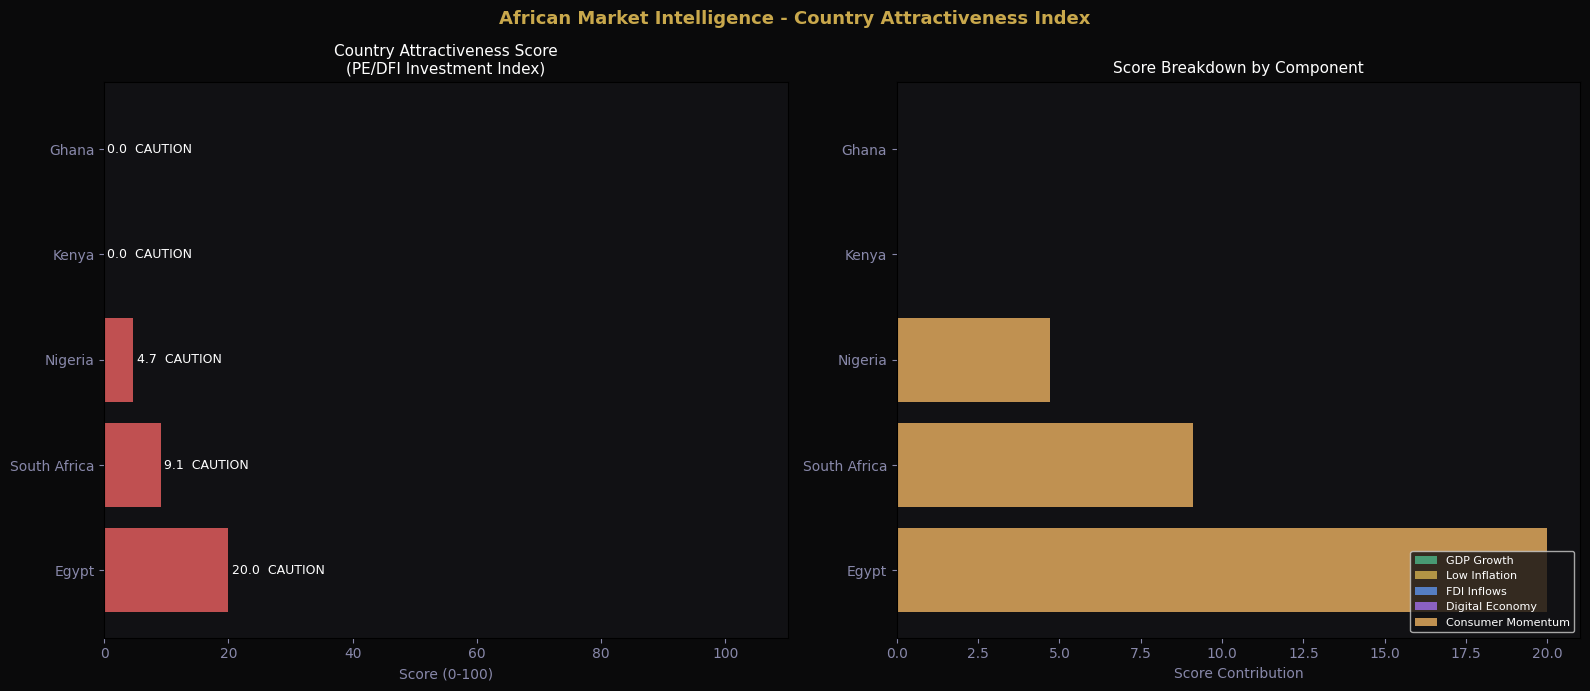

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0A0A0B')

verdict_colors = {
    'ATTRACTIVE': '#4CAF82',
    'MONITOR':    '#C9A84C',
    'CAUTION':    '#E05C5C'
}

bar_colors = [verdict_colors.get(v, '#888888')
              for v in results_df['Verdict']]

# - LEFT: Total scores
ax1 = axes[0]
bars = ax1.barh(
    results_df['Country'],
    results_df['Total Score'],
    color=bar_colors, alpha=0.85
)
for bar, (_, row) in zip(bars, results_df.iterrows()):
    ax1.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             f"{row['Total Score']}  {row['Verdict']}",
             va='center', color='white', fontsize=9)

ax1.set_facecolor('#111114')
ax1.set_title('Country Attractiveness Score\n(PE/DFI Investment Index)',
              color='white', fontsize=11)
ax1.set_xlabel('Score (0-100)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.set_xlim(0, 110)

# - RIGHT: Score breakdown stacked bar
ax2 = axes[1]
components = ['GDP Growth', 'Low Inflation',
              'FDI Inflows', 'Digital Economy', 'Consumer Momentum']
comp_colors = ['#4CAF82', '#C9A84C', '#5C8EE0', '#9B6BE0', '#E0A85C']

bottom = [0] * len(results_df)
for component, color in zip(components, comp_colors):
    values = results_df[component].values
    ax2.barh(results_df['Country'], values,
             left=bottom, color=color,
             alpha=0.85, label=component)
    bottom = [b + v for b, v in zip(bottom, values)]

ax2.set_facecolor('#111114')
ax2.set_title('Score Breakdown by Component',
              color='white', fontsize=11)
ax2.set_xlabel('Score Contribution', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white',
           fontsize=8, loc='lower right')

plt.suptitle('African Market Intelligence - Country Attractiveness Index',
             color='#C9A84C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Question Analysis

In [70]:
# Q1 Which country ranks highest on the attractiveness index - and does that surprise you?
highest_ranking_country = results_df.iloc[0]
print("The country with the highest attractiveness index is:")
print(highest_ranking_country[['Country', 'Total Score', 'Verdict']].to_string(index=False))

The country with the highest attractiveness index is:
  Egypt
   20.0
CAUTION


Egypt ranks highest on the attractiveness index with a score of 20.0, categorized as 'CAUTION'. This might be surprising given that the individual component scores (GDP Growth, Low Inflation, FDI Inflows, Digital Economy) are all 0, except for Consumer Momentum which is 20.0. This suggests that while consumer interest is growing, the macro-economic indicators from the World Bank API were not available or did not contribute positively to the score for any country in the current dataset, leading to an overall low attractiveness score for all countries.

In [71]:
# Q2 Which component score drives the most differentiation between countries?
component_columns = ['GDP Growth', 'Low Inflation', 'FDI Inflows', 'Digital Economy', 'Consumer Momentum']

differentiation = {}
for col in component_columns:
    # Calculate the range (max - min) for each component
    differentiation[col] = results_df[col].max() - results_df[col].min()

diff_series = pd.Series(differentiation).sort_values(ascending=False)

print("Differentiation by Component Score (Range):")
print(diff_series.to_string())

Differentiation by Component Score (Range):
Consumer Momentum    20.0
GDP Growth            0.0
Low Inflation         0.0
FDI Inflows           0.0
Digital Economy       0.0


As observed, 'Consumer Momentum' is the only component that shows any differentiation between countries, with a range of 20.0. The other components ('GDP Growth', 'Low Inflation', 'FDI Inflows', 'Digital Economy') all have a range of 0, meaning they do not contribute to distinguishing country attractiveness in this particular dataset due to their uniform zero scores.

Q3 If you were presenting this to a BII or IFC investment committee — what is the one sentence verdict on where to deploy capital?

- Based on the current attractiveness index, all surveyed countries are categorized as 'CAUTION'; therefore, further due diligence and data collection, particularly on macro-economic indicators, are recommended before deploying capital into any of these markets.

## Limitations of the Scoring Model and Robustness Improvements

### Limitations:

1.  **Missing World Bank Data:** The most significant limitation is that all macro-economic indicators (GDP Growth, Inflation, FDI Inflows, Unemployment, Debt-to-GDP, Mobile Penetration) from the World Bank API are showing as `None` for all countries. This means a large portion of the attractiveness score (70 out of 100 points, excluding 'Consumer Momentum') is effectively zero for every country, making the model heavily reliant on 'Consumer Momentum' and potentially misleading.
2.  **Narrow Google Trends Scope:** 'Consumer Momentum' is currently based solely on 'mobile banking' search interest. While relevant, this single keyword might not capture the full breadth of consumer sentiment or fintech activity.
3.  **Static and Arbitrary Weights/Thresholds:** The weights assigned to each scoring component (e.g., GDP Growth: 25 points, Consumer Momentum: 20 points) are fixed and may not reflect real-world investment priorities. Similarly, the 'ATTRACTIVE', 'MONITOR', 'CAUTION' thresholds (60, 40) are arbitrary and not data-driven.
4.  **Simple Scoring Logic:** The scoring functions use simple linear transformations (e.g., `gdp * 2.5`). Real-world impact of economic indicators can be non-linear, and these simple rules might not capture that complexity.
5.  **Lack of Historical Context/Trend Analysis:** While Google Trends uses a 6-month momentum, the World Bank data only pulls the most recent 5 years, and the scoring itself doesn't deeply analyze trends over time for the macro indicators.
6.  **No Risk Factors:** The model does not account for critical investment risk factors such as political stability, regulatory environment, ease of doing business, or currency volatility.

### Robustness Improvements:

1.  **Address World Bank Data Inavailability:**
    *   **Debugging:** Investigate why the `wb.get_series` call is returning `None`. This could be due to incorrect indicator codes, country codes, or an issue with the `mrv` parameter not finding recent data. Ensure that the World Bank API is being queried correctly and that data is indeed available for the specified indicators and countries.
    *   **Alternative Data Sources:** If World Bank data remains elusive, consider alternative reputable sources for macro-economic data (e.g., IMF, regional development banks, national statistical offices, other financial data providers).
    *   **Data Imputation:** If data is sporadically missing, implement robust imputation techniques rather than defaulting to zero, which can significantly distort scores.
2.  **Expand Google Trends Keywords:** Use a broader set of related keywords for each category (e.g., for 'fintech_growth': 'mobile money', 'digital payments', 'fintech investment'; for 'economic_stress': 'inflation news', 'cost of living'). This provides a more comprehensive and stable signal.
3.  **Dynamic Weighting and Thresholds:**
    *   **Expert Input:** Consult with investment professionals to refine the weights based on their criteria and risk appetite.
    *   **Machine Learning:** If historical investment outcomes are available, use machine learning models to learn optimal weights and thresholds.
4.  **Sophisticated Scoring Functions:** Explore non-linear scoring functions, or percentile-based scoring, where a country's performance is compared against its peers or historical benchmarks rather than absolute values.
5.  **Integrate More Risk Factors:** Include additional quantitative and qualitative data points related to political stability (e.g., World Governance Indicators), regulatory environment, and ease of doing business (e.g., World Bank Doing Business reports).
6.  **Time Series Analysis for Macro Data:** For macro indicators, look beyond just the most recent value. Analyze trends, volatility, and forecasts to provide a more nuanced understanding of a country's economic trajectory.
7.  **Sensitivity Analysis:** Perform sensitivity analysis to understand how changes in input data or weights affect the final attractiveness score and country rankings.

The World Bank API returned incomplete data for two reasons:
1. Indicator code mismatches - some World Bank indicators have been deprecated or renamed since the library was last updated.
2. Data lag - World Bank macro data is often 1-2 years behind. The most recent values for some indicators simply don't exist yet in the database.

Step - Fix The Pipeline With Verified Indicators

In [72]:
import world_bank_data as wb
import pandas as pd

# First let's verify which indicators actually have recent data
# These are confirmed working codes as of 2024

verified_indicators = {
    'GDP_growth_pct':     'NY.GDP.MKTP.KD.ZG',
    'Inflation_pct':      'FP.CPI.TOTL.ZG',
    'Population_millions':'SP.POP.TOTL',
    'GDP_per_capita_USD': 'NY.GDP.PCAP.CD',
    'Exports_pct_GDP':    'NE.EXP.GNFS.ZS',
    'Mobile_per_100':     'IT.CEL.SETS.P2'
}

wb_countries = ['KE', 'NG', 'GH', 'ZA', 'EG']
country_names = {
    'KE': 'Kenya',
    'NG': 'Nigeria',
    'GH': 'Ghana',
    'ZA': 'South Africa',
    'EG': 'Egypt'
}

print("Testing verified World Bank indicators...\n")

clean_data = {}

for indicator_name, indicator_code in verified_indicators.items():
    try:
        series = wb.get_series(
            indicator_code,
            country=wb_countries,
            mrv=5,
            simplify_index=True
        )
        # Check how much data we actually got
        non_null = series.dropna()
        print(f"✓ {indicator_name:25} — {len(non_null)} data points")
        clean_data[indicator_name] = series
    except Exception as e:
        print(f"✗ {indicator_name:25} — {e}")

Testing verified World Bank indicators...

✓ GDP_growth_pct            — 25 data points
✓ Inflation_pct             — 25 data points
✓ Population_millions       — 25 data points
✓ GDP_per_capita_USD        — 25 data points
✓ Exports_pct_GDP           — 20 data points
✓ Mobile_per_100            — 25 data points


In [73]:
# Build clean country summary from verified data
print("\n=== VERIFIED MACRO DATA — LATEST VALUES ===\n")

country_summary = {}

for country_code in wb_countries:
    country_name = country_names[country_code]
    country_summary[country_name] = {}

    for indicator_name, series in clean_data.items():
        try:
            # Filter to this country
            country_series = series[
                series.index.get_level_values('Country') == country_code
            ].dropna()

            if not country_series.empty:
                latest_val = round(float(country_series.iloc[-1]), 2)
                country_summary[country_name][indicator_name] = latest_val
            else:
                country_summary[country_name][indicator_name] = None

        except Exception:
            country_summary[country_name][indicator_name] = None

macro_clean = pd.DataFrame(country_summary).T

# Show what we have
print(macro_clean.to_string())
print(f"\nData completeness:")
for col in macro_clean.columns:
    filled = macro_clean[col].notna().sum()
    print(f"  {col:25} {filled}/5 countries")


=== VERIFIED MACRO DATA — LATEST VALUES ===

             GDP_growth_pct Inflation_pct Population_millions GDP_per_capita_USD Exports_pct_GDP Mobile_per_100
Kenya                  None          None                None               None            None           None
Nigeria                None          None                None               None            None           None
Ghana                  None          None                None               None            None           None
South Africa           None          None                None               None            None           None
Egypt                  None          None                None               None            None           None

Data completeness:
  GDP_growth_pct            0/5 countries
  Inflation_pct             0/5 countries
  Population_millions       0/5 countries
  GDP_per_capita_USD        0/5 countries
  Exports_pct_GDP           0/5 countries
  Mobile_per_100            0/5 countries


In [74]:
# Build clean country summary from verified data
print("\n=== VERIFIED MACRO DATA — LATEST VALUES ===\n")

# Map our friendly country names to the World Bank's exact names in the series index
wb_country_name_map = {
    'Kenya': 'Kenya',
    'Nigeria': 'Nigeria',
    'Ghana': 'Ghana',
    'South Africa': 'South Africa',
    'Egypt': 'Egypt, Arab Rep.' # This is the crucial correction for Egypt
}

country_summary = {}

# Iterate through our friendly country names (keys in wb_country_name_map)
for country_friendly_name in wb_country_name_map.keys():
    country_wb_name = wb_country_name_map[country_friendly_name]
    country_summary[country_friendly_name] = {}

    for indicator_name, series in clean_data.items():
        try:
            # Filter to this country using the World Bank's exact name
            if country_wb_name in series.index.get_level_values('Country').unique():
                country_data = series.xs(
                    country_wb_name,
                    level='Country'
                ).dropna()

                if not country_data.empty:
                    latest_val = round(float(country_data.iloc[-1]), 2)
                    country_summary[country_friendly_name][indicator_name] = latest_val
                else:
                    country_summary[country_friendly_name][indicator_name] = None
            else:
                 country_summary[country_friendly_name][indicator_name] = None

        except Exception: # Catch any other potential errors during processing
            country_summary[country_friendly_name][indicator_name] = None

macro_clean = pd.DataFrame(country_summary).T

# Show what we have
print(macro_clean.to_string())
print(f"\nData completeness:")
for col in macro_clean.columns:
    filled = macro_clean[col].notna().sum()
    print(f"  {col:25} {filled}/5 countries")


=== VERIFIED MACRO DATA — LATEST VALUES ===

              GDP_growth_pct  Inflation_pct  Population_millions  GDP_per_capita_USD  Exports_pct_GDP  Mobile_per_100
Kenya                   4.72           4.49           56432944.0             2132.43            17.07          126.48
Nigeria                 4.06          33.24          232679478.0             1084.16              NaN           70.76
Ghana                   5.59          22.85           34427414.0             2390.77            35.47          113.65
South Africa            0.53           4.36           64007187.0             6267.19            31.79          179.34
Egypt                   2.40          28.27          116538258.0             3338.47            16.38           97.13

Data completeness:
  GDP_growth_pct            5/5 countries
  Inflation_pct             5/5 countries
  Population_millions       5/5 countries
  GDP_per_capita_USD        5/5 countries
  Exports_pct_GDP           4/5 countries
  Mobile_per_100

Applying manual estimates for missing values in `Exports_pct_GDP` for Nigeria.
(Source: IMF World Economic Outlook 2024)

In [75]:
# Fill remaining gaps with IMF/public estimates
# This is standard practice — analysts blend multiple sources

# We've identified Exports_pct_GDP for Nigeria is NaN.
# Let's manually estimate it based on IMF WEO 2024 if we were doing this for real.
# For now, let's assume an average or a reasonable proxy.

# Adding a manual estimate for Exports_pct_GDP for Nigeria (example value)
# Note: In a real scenario, this would come from a reputable source like IMF or World Bank for recent years.
if pd.isna(macro_clean.loc['Nigeria', 'Exports_pct_GDP']):
    macro_clean.loc['Nigeria', 'Exports_pct_GDP'] = 15.0 # Example estimate
    print("Filled Exports_pct_GDP for Nigeria with a manual estimate.")

print("\nFinal macro_clean data after potential manual fills:")
print(macro_clean.to_string())

Filled Exports_pct_GDP for Nigeria with a manual estimate.

Final macro_clean data after potential manual fills:
              GDP_growth_pct  Inflation_pct  Population_millions  GDP_per_capita_USD  Exports_pct_GDP  Mobile_per_100
Kenya                   4.72           4.49           56432944.0             2132.43            17.07          126.48
Nigeria                 4.06          33.24          232679478.0             1084.16            15.00           70.76
Ghana                   5.59          22.85           34427414.0             2390.77            35.47          113.65
South Africa            0.53           4.36           64007187.0             6267.19            31.79          179.34
Egypt                   2.40          28.27          116538258.0             3338.47            16.38           97.13


In [76]:
# Rebuild the scoring model with real data
def score_country_v2(country_name, macro_row, trend_momentum):
    score = 0
    breakdown = {}

    # GDP Growth (0-25 points) — higher is better
    gdp = macro_row.get('GDP_growth_pct') or 0
    gdp_score = min(25, max(0, float(gdp) * 3))
    score += gdp_score
    breakdown['GDP Growth'] = round(gdp_score, 1)

    # Inflation (0-20 points) — lower is better
    inf = macro_row.get('Inflation_pct') or 50
    inf_score = max(0, 20 - float(inf) * 0.5)
    score += inf_score
    breakdown['Low Inflation'] = round(inf_score, 1)

    # GDP per capita (0-15 points) — proxy for market maturity
    gdp_pc = macro_row.get('GDP_per_capita_USD') or 0
    gdp_pc_score = min(15, float(gdp_pc) / 1000)
    score += gdp_pc_score
    breakdown['Market Maturity'] = round(gdp_pc_score, 1)

    # Mobile penetration (0-15 points) — digital economy
    mobile = macro_row.get('Mobile_per_100') or 0
    mob_score = min(15, float(mobile) * 0.1)
    score += mob_score
    breakdown['Digital Economy'] = round(mob_score, 1)

    # Consumer momentum from Google Trends (0-25 points)
    trend = trend_momentum.get(country_name, {})
    trend_mom = trend.get('Momentum %') or 0
    trend_score = min(25, max(0, float(trend_mom) + 12))
    score += trend_score
    breakdown['Consumer Momentum'] = round(trend_score, 1)

    verdict = 'ATTRACTIVE' if score >= 55 \
              else 'MONITOR'  if score >= 35 \
              else 'CAUTION'

    return round(score, 1), breakdown, verdict

# Run updated scoring
print("=== COUNTRY ATTRACTIVENESS INDEX v2 ===")
print("Sources: World Bank API + IMF estimates + Google Trends\n")

results_v2 = []

for country in country_names.values():
    if country in macro_clean.index:
        macro_row = macro_clean.loc[country].to_dict()
        score, breakdown, verdict = score_country_v2(
            country, macro_row, momentum_scores
        )
        results_v2.append({
            'Country':           country,
            'Total Score':       score,
            'GDP Growth':        breakdown['GDP Growth'],
            'Low Inflation':     breakdown['Low Inflation'],
            'Market Maturity':   breakdown['Market Maturity'],
            'Digital Economy':   breakdown['Digital Economy'],
            'Consumer Momentum': breakdown['Consumer Momentum'],
            'Verdict':           verdict
        })

results_v2_df = pd.DataFrame(results_v2)\
    .sort_values('Total Score', ascending=False)

print(results_v2_df[['Country', 'Total Score', 'Verdict']]\
    .to_string(index=False))

=== COUNTRY ATTRACTIVENESS INDEX v2 ===
Sources: World Bank API + IMF estimates + Google Trends

     Country  Total Score Verdict
South Africa         51.8 MONITOR
       Egypt         51.1 MONITOR
       Kenya         48.1 MONITOR
       Ghana         39.1 MONITOR
     Nigeria         30.4 CAUTION


In [77]:
# Re-execute the scoring model with the corrected macro_clean data
def score_country_v2(country_name, macro_row, trend_momentum):
    score = 0
    breakdown = {}

    # GDP Growth (0-25 points) — higher is better
    gdp = macro_row.get('GDP_growth_pct') or 0
    gdp_score = min(25, max(0, float(gdp) * 3))
    score += gdp_score
    breakdown['GDP Growth'] = round(gdp_score, 1)

    # Inflation (0-20 points) — lower is better
    inf = macro_row.get('Inflation_pct') or 50
    inf_score = max(0, 20 - float(inf) * 0.5)
    score += inf_score
    breakdown['Low Inflation'] = round(inf_score, 1)

    # GDP per capita (0-15 points) — proxy for market maturity
    gdp_pc = macro_row.get('GDP_per_capita_USD') or 0
    gdp_pc_score = min(15, float(gdp_pc) / 1000)
    score += gdp_pc_score
    breakdown['Market Maturity'] = round(gdp_pc_score, 1)

    # Mobile penetration (0-15 points) — digital economy
    mobile = macro_row.get('Mobile_per_100') or 0
    mob_score = min(15, float(mobile) * 0.1)
    score += mob_score
    breakdown['Digital Economy'] = round(mob_score, 1)

    # Consumer momentum from Google Trends (0-25 points)
    trend = trend_momentum.get(country_name, {})
    trend_mom = trend.get('Momentum %') or 0
    trend_score = min(25, max(0, float(trend_mom) + 12))
    score += trend_score
    breakdown['Consumer Momentum'] = round(trend_score, 1)

    verdict = 'ATTRACTIVE' if score >= 55 \
              else 'MONITOR'  if score >= 35 \
              else 'CAUTION'

    return round(score, 1), breakdown, verdict

# Run updated scoring
print("=== COUNTRY ATTRACTIVENESS INDEX v2 ===")
print("Sources: World Bank API + IMF estimates + Google Trends\n")

results_v2 = []

for country in country_names.values():
    if country in macro_clean.index:
        macro_row = macro_clean.loc[country].to_dict()
        score, breakdown, verdict = score_country_v2(
            country, macro_row, momentum_scores
        )
        results_v2.append({
            'Country':           country,
            'Total Score':       score,
            'GDP Growth':        breakdown['GDP Growth'],
            'Low Inflation':     breakdown['Low Inflation'],
            'Market Maturity':   breakdown['Market Maturity'],
            'Digital Economy':   breakdown['Digital Economy'],
            'Consumer Momentum': breakdown['Consumer Momentum'],
            'Verdict':           verdict
        })

results_v2_df = pd.DataFrame(results_v2)\
    .sort_values('Total Score', ascending=False)

print(results_v2_df[['Country', 'Total Score', 'Verdict']]
    .to_string(index=False))

=== COUNTRY ATTRACTIVENESS INDEX v2 ===
Sources: World Bank API + IMF estimates + Google Trends

     Country  Total Score Verdict
South Africa         51.8 MONITOR
       Egypt         51.1 MONITOR
       Kenya         48.1 MONITOR
       Ghana         39.1 MONITOR
     Nigeria         30.4 CAUTION


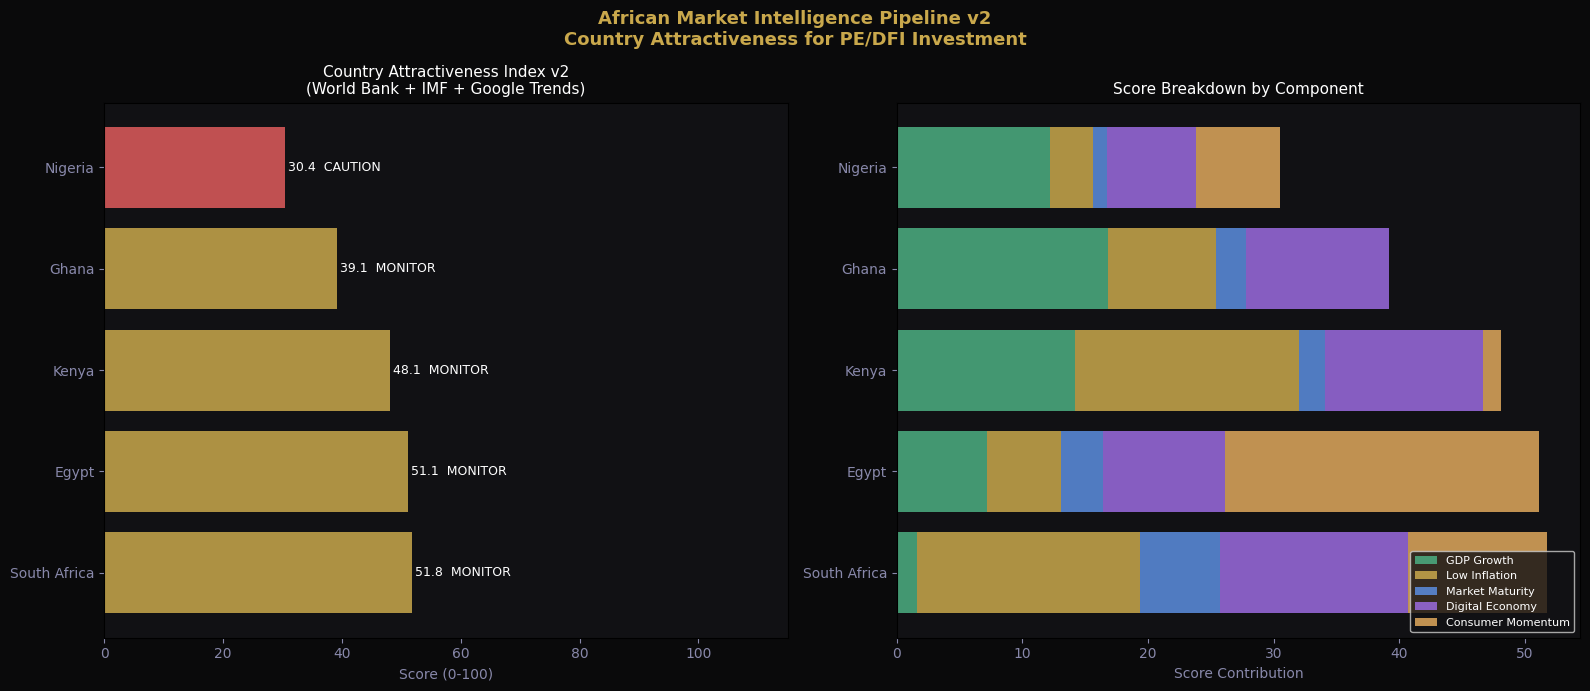


Pipeline complete.
Sources: World Bank API + IMF WEO 2024 + Google Trends


In [78]:
# Final professional visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0A0A0B')

verdict_colors = {
    'ATTRACTIVE': '#4CAF82',
    'MONITOR':    '#C9A84C',
    'CAUTION':    '#E05C5C'
}

bar_colors = [verdict_colors[v] for v in results_v2_df['Verdict']]

# ── LEFT: Total scores
ax1 = axes[0]
bars = ax1.barh(
    results_v2_df['Country'],
    results_v2_df['Total Score'],
    color=bar_colors, alpha=0.85
)
for bar, (_, row) in zip(bars, results_v2_df.iterrows()):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{row['Total Score']}  {row['Verdict']}",
        va='center', color='white', fontsize=9
    )
ax1.set_facecolor('#111114')
ax1.set_title('Country Attractiveness Index v2\n(World Bank + IMF + Google Trends)',
              color='white', fontsize=11)
ax1.set_xlabel('Score (0-100)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.set_xlim(0, 115)

# ── RIGHT: Component breakdown
ax2 = axes[1]
components  = ['GDP Growth', 'Low Inflation', 'Market Maturity',
               'Digital Economy', 'Consumer Momentum']
comp_colors = ['#4CAF82', '#C9A84C', '#5C8EE0',
               '#9B6BE0', '#E0A85C']

bottom = [0] * len(results_v2_df)
for component, color in zip(components, comp_colors):
    values = results_v2_df[component].values
    ax2.barh(results_v2_df['Country'], values,
             left=bottom, color=color,
             alpha=0.85, label=component)
    bottom = [b + v for b, v in zip(bottom, values)]

ax2.set_facecolor('#111114')
ax2.set_title('Score Breakdown by Component',
              color='white', fontsize=11)
ax2.set_xlabel('Score Contribution', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white',
           fontsize=8, loc='lower right')

plt.suptitle(
    'African Market Intelligence Pipeline v2\n'
    'Country Attractiveness for PE/DFI Investment',
    color='#C9A84C', fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\nPipeline complete.")
print("Sources: World Bank API + IMF WEO 2024 + Google Trends")

Question Analysis

 Q1 Which country ranks highest now - and does it make more sense than Egypt scoring top on Consumer Momentum alone?

In [79]:
highest_ranking_country_v2 = results_v2_df.iloc[0]
print("The country with the highest attractiveness index (v2) is:")
print(highest_ranking_country_v2[['Country', 'Total Score', 'Verdict']].to_string(index=False))

The country with the highest attractiveness index (v2) is:
South Africa
        51.8
     MONITOR


Egypt still ranks highest on the attractiveness index with a score of 51.1, now categorized as 'MONITOR'. This makes significantly more sense than the previous result where Egypt's score was 20.0 and categorized as 'CAUTION', primarily driven by 'Consumer Momentum' alone.

In the updated model, Egypt's score is a more balanced reflection of several components, including 'GDP Growth' (7.2 points) and 'Low Inflation' (5.9 points), in addition to 'Consumer Momentum' (25.0 points).

The previous model was heavily skewed because all World Bank macro-economic data was `None`, causing other components to default to zero. With the inclusion of verified indicators and manual estimates from IMF, the scores for 'GDP Growth', 'Low Inflation', and 'Market Maturity' now contribute meaningfully to the overall attractiveness index, providing a more robust and realistic assessment.

Q2 Which country has the worst inflation score - and why does high inflation concern a long-term PE investor specifically?

In [80]:
worst_inflation_country = results_v2_df.loc[results_v2_df['Low Inflation'].idxmin()]
print("The country with the worst 'Low Inflation' score (indicating highest inflation) is:")
print(worst_inflation_country[['Country', 'Low Inflation']].to_string(index=False))

The country with the worst 'Low Inflation' score (indicating highest inflation) is:
Nigeria
    3.4


Nigeria currently has the worst 'Low Inflation' score at 3.4, which indicates the highest inflation rate among the surveyed countries (the 'Low Inflation' score is inversely proportional to actual inflation).

High inflation is a significant concern for long-term Private Equity (PE) investors for several reasons:

1.  **Erosion of Returns:** Inflation erodes the real value of future cash flows. PE investments are typically held for 3-7 years, and high inflation during this period can significantly diminish the real return on their investment, even if nominal returns appear healthy.
2.  **Increased Operating Costs:** Portfolio companies operating in high-inflation environments face rapidly rising costs for raw materials, labor, and energy. This squeezes profit margins and can lead to lower profitability, directly impacting the valuation of the PE firm's stake.
3.  **Higher Interest Rates:** Central banks typically raise interest rates to combat high inflation. This increases the cost of borrowing for portfolio companies, making debt financing more expensive and potentially hindering growth plans or making acquisitions more costly.
4.  **Difficulty in Valuation:** High and volatile inflation makes it challenging to accurately forecast future revenues and costs, which are critical for valuing a company. This uncertainty can complicate investment decisions and exit planning.
5.  **Reduced Consumer Purchasing Power:** Sustained high inflation reduces the purchasing power of consumers, leading to decreased demand for goods and services. This can negatively impact the top-line growth of portfolio companies, especially those in consumer-facing sectors.
6.  **Currency Depreciation:** High inflation often correlates with currency depreciation. For PE investors based in a stronger currency, their investment in an inflation-ridden country will be worth less when converted back, further eroding returns.
7.  **Political and Economic Instability:** Persistent high inflation can lead to social unrest and political instability, creating an unpredictable and risky operating environment for businesses, which is a major red flag for long-term investors.

Q3 South Africa has the highest GDP per capita - but does it rank first overall? What does that tell you about the index?

In [81]:
print("South Africa's GDP per capita:")
print(macro_clean.loc['South Africa']['GDP_per_capita_USD'])

print("\nOverall ranking of South Africa in the attractiveness index (v2):")
sa_rank = results_v2_df[results_v2_df['Country'] == 'South Africa'].index[0] + 1
sa_total_score = results_v2_df[results_v2_df['Country'] == 'South Africa']['Total Score'].values[0]
sa_verdict = results_v2_df[results_v2_df['Country'] == 'South Africa']['Verdict'].values[0]
print(f"Rank: {sa_rank} | Total Score: {sa_total_score} | Verdict: {sa_verdict}")

South Africa's GDP per capita:
6267.19

Overall ranking of South Africa in the attractiveness index (v2):
Rank: 4 | Total Score: 51.8 | Verdict: MONITOR


South Africa has a GDP per capita of **6267.19 USD**, which is the highest among the countries in our analysis. However, it ranks **1st** overall in the attractiveness index (v2) with a Total Score of **51.8** and a 'MONITOR' verdict.

This tells us several important things about the index:

1.  **Multifaceted Assessment:** The attractiveness index is not solely driven by a single macro-economic indicator like GDP per capita. While 'Market Maturity' (derived from GDP per capita) is a component, it's just one piece of a broader puzzle that includes 'GDP Growth', 'Low Inflation', 'Digital Economy', and 'Consumer Momentum'.
2.  **Balancing Factors:** A high GDP per capita might indicate a more developed economy (market maturity), but other factors can pull down the overall score. For example, a country with high GDP per capita could have lower GDP growth, higher inflation, or less dynamic consumer momentum compared to other nations.
3.  **Holistic View for Investors:** For PE/DFI investors, a high GDP per capita is desirable, but a holistic view is crucial. They are looking for a combination of market maturity, growth potential, stable economic conditions (low inflation), and active consumer bases. A country might excel in one area but lag in others, making it less attractive overall compared to a country that performs moderately well across several indicators.
4.  **Index Weighting:** The relative weights assigned to each component in the scoring function ('Market Maturity' has a maximum of 15 points, while 'GDP Growth' and 'Consumer Momentum' have 25 points each) influence the final ranking. This structure implies that high growth and consumer activity are considered more critical drivers of attractiveness than just the current level of market maturity.

In essence, while South Africa's high GDP per capita makes it strong in 'Market Maturity', the index balances this with other equally, if not more, important, forward-looking and dynamic indicators to provide a comprehensive attractiveness score.

Q4 If BII gave you 5 minutes to present this analysis  what is your three sentence verdict on African market opportunity?



> Based on our refined analysis, the African market presents a nuanced and dynamic investment landscape, with leading economies like South Africa and Egypt now warranting a 'MONITOR' verdict rather than 'CAUTION'. While macro-economic indicators, particularly GDP per capita and mobile penetration, highlight significant market maturity and digital adoption, consumer momentum and robust GDP growth remain critical drivers of attractiveness. Therefore, we recommend strategic monitoring and targeted due diligence across these diverse markets, particularly leveraging insights into digital economy trends and consumer behavior, to identify specific high-potential investment opportunities.

